### import utils

In [2]:
from a_utils import (
    keep_rows_with_any_filled,
    keep_positives,
    get_sym_severity,
    get_symptom_severity_score,
    is_abnormal_cxr,
    open_data,
    plot_fill_rates,
    log_column_names_with_single_unique_value,
    SYMPTOMS,
    VITALS,
)

### load data

In [3]:
data = open_data()
log_column_names_with_single_unique_value(data)


### plot fill rates

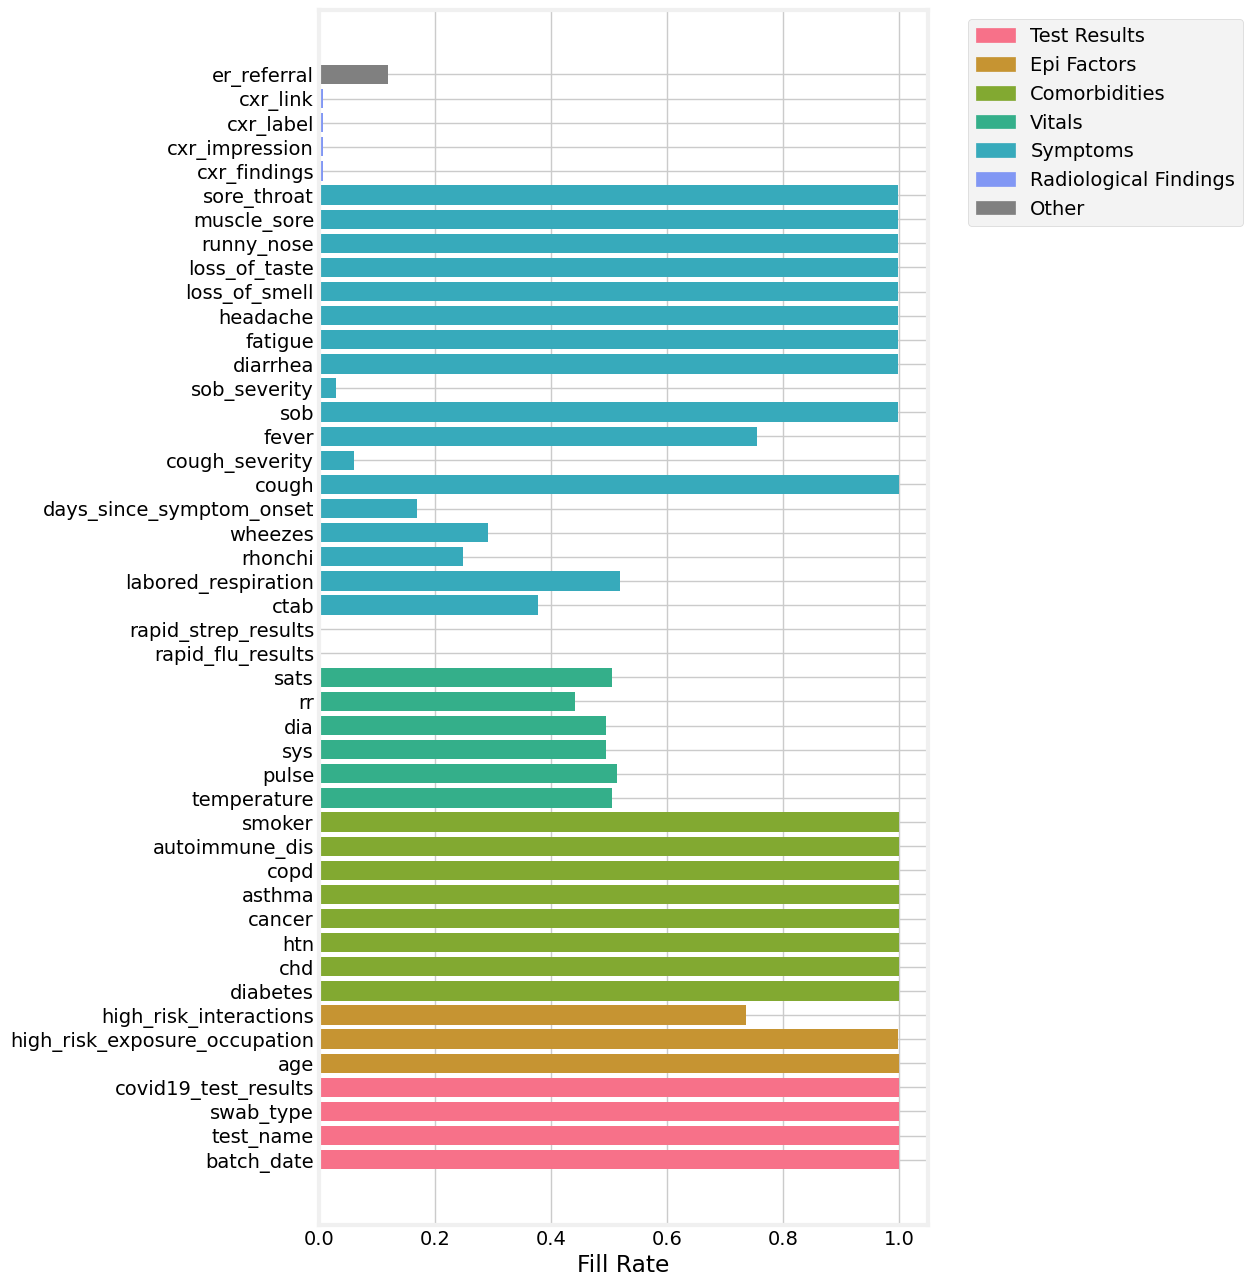

In [4]:
plot_fill_rates(data)


### process and filter data

In [ ]:
positive_patients = keep_positives(data)
symptomatic_patients = keep_rows_with_any_filled(data, SYMPTOMS)
patients_with_vitals = keep_rows_with_any_filled(data, VITALS, col_type='numeric')

has_cxr = ~data['cxr_impression'].isnull()

# add a column for whether the cxr impression is abnormal or not, only for rows that have a cxr impression
data.loc[has_cxr, 'is_abnormal_cxr'] = data.loc[
    has_cxr, 'cxr_impression'
].apply(is_abnormal_cxr)

# add a column for the number of symptoms, only for rows that have at least one symptom filled in
data.loc[:, 'num_symptoms'] = data.loc[:, :].apply(
    lambda x: sum(1 for sym in SYMPTOMS if x[sym] == True), axis=1
)

# add a column for the symptom severity score, only for rows that have at least one symptom filled in
data['severity_score'] = data.apply(
    lambda x: get_symptom_severity_score(x), axis=1
)
data['sym_severity'] = data.severity_score.apply(
    lambda x: get_sym_severity(x)
)


INFO:root:Filtering out patients...


INFO:root:    ---- 93995 --> 26577 (28.27%)
INFO:root:Filtering out patients...
INFO:root:    ---- 93995 --> 49341 (52.49%)
